# $visit_n - visit_1 \rightarrow fatigue_n - fatigue_1$
$\Delta visit \rightarrow \Delta fatigue$ \
Finds difference from **previous** visit to **next** visit **using weekly DMOs**

In [17]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.evaluation import Evaluation
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.core.data_transforms import Transform
from src.train.train_random_forest import XVRandomForest

import torch

In [18]:
K_FOLDS = 5
N_VISITS = 4

In [19]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [20]:
# dmo_features = [
#     "cadence_30_p90",
#     "cadence_30_avg",
#     "ws_30_p90",
#     "strlen_1030_avg",
#     "cadence_all_avg",
# ]

In [21]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [22]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [23]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [24]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [25]:
print(dmo_data.shape)

torch.Size([428, 4, 7, 25])


In [26]:
# flatten to weekly summaries (this keeps patients consistant over the testing)
dmo_data = dmo_data.mean(axis=2)

In [27]:
# Min max normalise the labels globally

label_normaliser = Normaliser(MinMaxScaler())
dmo_labels = label_normaliser.scaler_fit_transform(dmo_labels)

In [28]:
patients, visits, features = dmo_data.shape

delta_visits = torch.zeros(patients, visits - 1, features)
for patient in range(patients):
    reference_visit = dmo_data[patient, 0]
    for visit in range(visits - 1):
        updated_visit = dmo_data[patient, visit + 1] - reference_visit
        delta_visits[patient, visit] = updated_visit 
        reference_visit = dmo_data[patient, visit + 1]

dmo_data = delta_visits.reshape(patients, (visits - 1), features)

In [29]:
patients, visits, labels = dmo_labels.shape
    
delta_labels = torch.zeros(patients, (visits - 1), labels)
for patient in range(patients):
    reference_label = dmo_labels[patient, :-1]
    
    delta_visits = dmo_labels[patient, 1:] - reference_label
    delta_labels[patient] = delta_visits
    reference_label = dmo_labels[patient, 1:]

dmo_labels = delta_labels.reshape(patients, (visits - 1), labels)


In [30]:
xvregressor = XVRandomForest(dmo_data, dmo_labels, k=K_FOLDS, seed=1234)
prediction, actual = xvregressor.train_cross_validation(label_normaliser)

-0.002683468743499118
-0.018504705473019634
-0.02703319987776176
-0.030120442310573203
-0.06913034229255155


{'accuracy': 0.019470404984423675, 'Mean Squared Error': 33.77522277832031, 'Mean Absolute Error': 4.424853801727295, 'R^2': -0.02725818543312708}


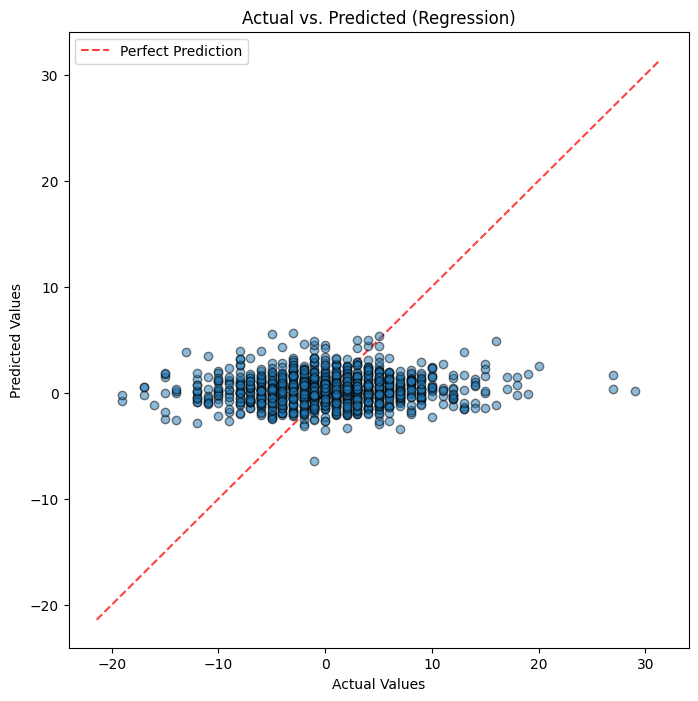

In [31]:
evaluation = Evaluation(prediction, actual)
print(evaluation.compute_all_metrics())
evaluation.evaluation_plot().show()